In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/Users/gautam/Desktop/MinneMUDAC2025/sorted_Training.csv', low_memory=False)

In [27]:
df['Completion Date'] = pd.to_datetime(df['Completion Date'])
df_filtered = df.dropna(subset=['Completion Date', 'Match Length']).copy()
df_filtered['Time Gap'] = df_filtered.groupby('Match ID 18Char')['Completion Date'].diff().dt.days
df_gaps = df_filtered.dropna(subset=['Time Gap'])

Correlation between time gap and Match Length:
               Time Gap  Match Length
Time Gap      1.000000      0.303351
Match Length  0.303351      1.000000


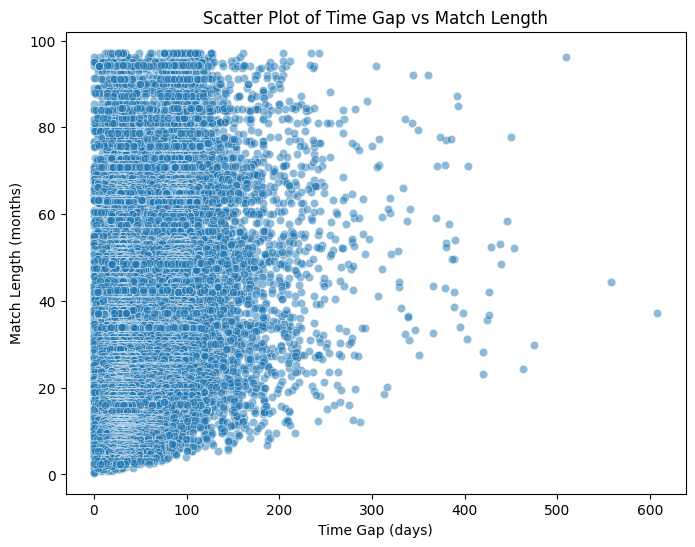

In [29]:
# correlation
correlation = df_gaps[['Time Gap', 'Match Length']].corr()
print("Correlation between time gap and Match Length:\n", correlation)

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_gaps, x='Time Gap', y='Match Length', alpha=0.5)
plt.xlabel('Time Gap (days)')
plt.ylabel('Match Length (months)')
plt.title('Scatter Plot of Time Gap vs Match Length')
plt.show()

In [36]:
# Compute average time gap per Match ID
df_avg_time_gap = df_gaps.groupby('Match ID 18Char').agg(
    avg_time_gap=('Time Gap', 'mean'),
    Match_Length=('Match Length', 'first')
).dropna()

# Compute correlation between average time gap and match length
avg_time_gap_correlation = df_avg_time_gap.corr()
print("Correlation between Average Time Gap and Match Length:\n", avg_time_gap_correlation)

Correlation between Average Time Gap and Match Length:
               avg_time_gap  Match_Length
avg_time_gap      1.000000      0.551664
Match_Length      0.551664      1.000000


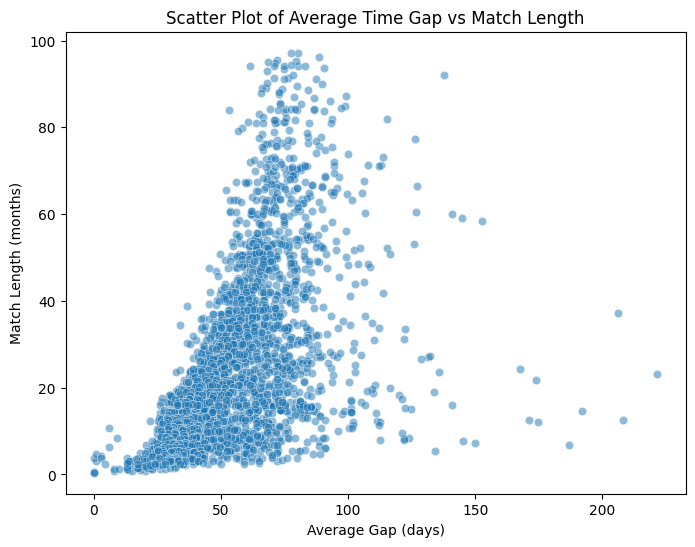

In [37]:
# Plot average time gap vs match length
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_avg_time_gap, x='avg_time_gap', y='Match_Length', alpha=0.5)
plt.xlabel('Average Gap (days)')
plt.ylabel('Match Length (months)')
plt.title('Scatter Plot of Average Time Gap vs Match Length')
plt.show()

In [39]:
# Compute frequency as the inverse of average time gap
df_avg_time_gap['Frequency'] = 1 / df_avg_time_gap['avg_time_gap']

# correlation between frequency and match length
freq_correlation = df_avg_time_gap[['Frequency', 'Match_Length']].corr()
print("Correlation between Frequency and Match Length:\n", freq_correlation)

Correlation between Frequency and Match Length:
               Frequency  Match_Length
Frequency      1.000000     -0.225412
Match_Length  -0.225412      1.000000


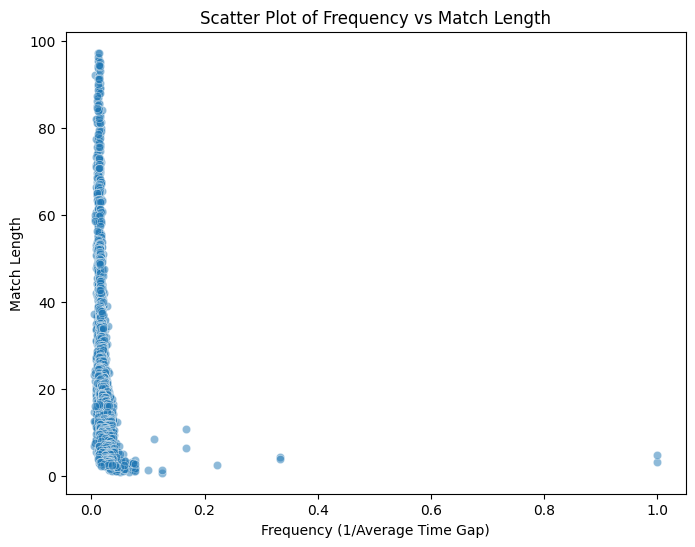

In [40]:
# Visualization for frequency vs match length
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_avg_time_gap, x='Frequency', y='Match_Length', alpha=0.5)
plt.xlabel('Frequency (1/Average Time Gap)')
plt.ylabel('Match Length')
plt.title('Scatter Plot of Frequency vs Match Length')
plt.show()